In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 데이터 불러오기

In [2]:
df = pd.read_csv('./data/hacktho_FF.csv')

# 데이터 전처리

## 컬럼명 한글로 변환

In [3]:
# 기존 컬럼명 → 한글명 매핑 딕셔너리
col_mapping_existing = {
    "age_range": "연령대",
    "gender": "성별",
    "region_1": "광역시도",
    "region_2": "시군구",
    "cust_grade": "고객등급구분코드",
    "job_dv": "직업구분코드",
    "foreigner_yn": "외국인여부",
    "delinq_hist_yn": "연체 이력 여부",
    "mob_yn": "모바일뱅킹 등록 여부",
    "openbank_yn": "오픈뱅킹 가입 여부",
    "cntr_svc_1": "창구 방문 업무1",
    "cntr_svc_2": "창구 방문 업무2",
    "cntr_svc_3": "창구 방문 업무3",
    "patroll_trf_yn": "급여이체 등록 여부",
    "won_loan_range": "원화대출잔액",
    "mortgage_loan_range": "주택담보대출",
    "cred_loan_range": "전세대출",
    "micro_loan_range": "소액대출",
    "lowinc_loan_range": "서민대출",
    "cor_loan_range": "기업대출잔액",
    "inout_bal_range": "입출금식예금평잔",
    "saving_bal_range": "적립식예금평잔",
    "deposit_bal_range": "거치식예금평잔",
    "etc_bal_range": "기타예금평잔",
    "fund_bal_range": "펀드잔액",
    "banca_bal_range": "방카슈랑스잔액",
    "knb_ast_range": "자산평잔_경남은행",
    "fn_ast_range": "자산평잔_투자증권",
    "sb_ast_range": "자산평잔_저축은행",
    "cc_txn_amt_range": "신용카드 거래액 합계",
    "chk_txn_amt_range": "체크카드 거래액 합계",
    "cc_txn_cnt_range": "신용카드 거래횟수",
    "chk_txn_cnt_range": "체크카드 거래횟수",
    "auto_trf_reg_cnt_range": "자동이체 등록 수",
    "mob_cnt_range": "모바일 이체 횟수",
    "atm_use_cnt_range": "자동화기기 이용 횟수",
    "partner_loan_yn": "제휴 대출 보유 여부",
    "join_period_range": "가입 기간",
    "cntr_svc_1_cnt_range": "창구 방문 업무1 횟수",
    "cntr_svc_2_cnt_range": "창구 방문 업무2 횟수",
    "cntr_svc_3_cnt_range": "창구 방문 업무3 횟수"
}

# 컬럼명 한글로 변경
df.rename(columns=col_mapping_existing, inplace=True)

## 대출 데이터 정합성 검사
- 원화대출잔액 = 가계대출잔액 + 기업대출잔액
- 전세대출, 주택담보대출은 가계대출에 포함됨
- 그러나, 전세대출, 주택담보대출 값이 원화대출잔액보다 큰 경우 존재 -> 제거 진행

In [4]:
def remove_inconsistent_loan_rows(df):

    print("=== 대출 데이터 정합성 검사 ===")
    
    before_count = len(df)
    print(f"검사 전 총 행 수: {before_count:,}")
    
    # 불일치 조건들 정의
    conditions = []
    condition_names = []
    
    # 1. 원화대출잔액 < 전세대출 (전세대출이 원화대출보다 클 수 없음)
    cond1 = df['원화대출잔액'] < df['전세대출']
    conditions.append(cond1)
    condition_names.append("원화대출 < 전세대출")
    
    # 2. 원화대출잔액 < 주택담보대출 (주택담보대출이 원화대출보다 클 수 없음)
    cond2 = df['원화대출잔액'] < df['주택담보대출']
    conditions.append(cond2)
    condition_names.append("원화대출 < 주택담보대출")
    
    # 3. 원화대출잔액 < 기업대출잔액 (기업대출이 원화대출보다 클 수 없음)
    cond3 = df['원화대출잔액'] < df['기업대출잔액']
    conditions.append(cond3)
    condition_names.append("원화대출 < 기업대출")
    
    # 4. 원화대출잔액 < 소액대출 (소액대출이 원화대출보다 클 수 없음)
    cond4 = df['원화대출잔액'] < df['소액대출']
    conditions.append(cond4)
    condition_names.append("원화대출 < 소액대출")
    
    # 5. 원화대출잔액 < 서민대출 (서민대출이 원화대출보다 클 수 없음)
    cond5 = df['원화대출잔액'] < df['서민대출']
    conditions.append(cond5)
    condition_names.append("원화대출 < 서민대출")
    
    # 각 조건별 불일치 건수 확인
    print("\n=== 불일치 조건별 분석 ===")
    total_inconsistent = pd.Series([False] * len(df))
    
    for i, (cond, name) in enumerate(zip(conditions, condition_names)):
        inconsistent_count = cond.sum()
        print(f"{i+1}. {name}: {inconsistent_count:,}건")
        
        if inconsistent_count > 0:
            # 샘플 출력 (최대 5개)
            sample_indices = df[cond].head().index
            print(f"   샘플 인덱스: {list(sample_indices)}")
        
        total_inconsistent = total_inconsistent | cond
    
    # 전체 불일치 건수
    total_inconsistent_count = total_inconsistent.sum()
    print(f"\n총 불일치 행 수: {total_inconsistent_count:,}")
    
    # 불일치 행 제거
    df_cleaned = df[~total_inconsistent].copy()
    after_count = len(df_cleaned)
    removed_count = before_count - after_count
    
    print(f"\n=== 정리 결과 ===")
    print(f"제거된 행 수: {removed_count:,}")
    print(f"남은 행 수: {after_count:,}")
    print(f"제거 비율: {removed_count/before_count*100:.2f}%")
    
    return df_cleaned

def verify_loan_consistency(df):
    """정리 후 데이터 일관성 검증"""
    
    print("\n=== 데이터 일관성 검증 ===")
    
    # 검증 조건들
    verifications = [
        (df['원화대출잔액'] >= df['전세대출'], "원화대출 >= 전세대출"),
        (df['원화대출잔액'] >= df['주택담보대출'], "원화대출 >= 주택담보대출"),
        (df['원화대출잔액'] >= df['기업대출잔액'], "원화대출 >= 기업대출"),
        (df['원화대출잔액'] >= df['소액대출'], "원화대출 >= 소액대출"),
        (df['원화대출잔액'] >= df['서민대출'], "원화대출 >= 서민대출")
    ]
    
    all_consistent = True
    
    for verification, description in verifications:
        violation_count = (~verification).sum()
        
        if violation_count == 0:
            print(f"✅ {description}: 모든 행 일관성 유지")
        else:
            print(f"❌ {description}: {violation_count:,}건 불일치 발견!")
            all_consistent = False
    
    if all_consistent:
        print("\n🎉 모든 대출 데이터가 논리적으로 일관됩니다!")
    else:
        print("\n⚠️  여전히 불일치가 존재합니다. 추가 검토가 필요합니다.")
    
    return all_consistent

def analyze_loan_distributions(df):
    """정리 후 대출 구간 분포 분석"""
    
    print("\n=== 대출 구간 분포 분석 ===")
    
    loan_columns = ['원화대출잔액', '전세대출', '주택담보대출', '기업대출잔액', '소액대출', '서민대출']
    
    for col in loan_columns:
        if col in df.columns:
            value_counts = df[col].value_counts().sort_index()
            print(f"\n{col} 분포:")
            for value, count in value_counts.items():
                percentage = count / len(df) * 100
                print(f"  {value}: {count:,}건 ({percentage:.1f}%)")

# 실행 함수
def clean_and_verify_loans(df):
    """전체 프로세스 실행"""
    
    print("대출 데이터 정합성 검사 및 정리를 시작합니다...\n")
    
    # 1. 불일치 행 제거
    df_cleaned = remove_inconsistent_loan_rows(df)
    
    # 2. 일관성 검증
    is_consistent = verify_loan_consistency(df_cleaned)
    
    # 3. 분포 분석 (선택적)
    analyze_loan_distributions(df_cleaned)
    
    return df_cleaned

# 사용 방법:
df_cleaned = clean_and_verify_loans(df)
df_cleaned.head()

대출 데이터 정합성 검사 및 정리를 시작합니다...

=== 대출 데이터 정합성 검사 ===
검사 전 총 행 수: 2,097,012

=== 불일치 조건별 분석 ===
1. 원화대출 < 전세대출: 210건
   샘플 인덱스: [838, 21423, 25066, 28312, 30872]
2. 원화대출 < 주택담보대출: 3,275건
   샘플 인덱스: [124, 325, 554, 578, 919]
3. 원화대출 < 기업대출: 0건
4. 원화대출 < 소액대출: 0건
5. 원화대출 < 서민대출: 0건

총 불일치 행 수: 3,485

=== 정리 결과 ===
제거된 행 수: 3,485
남은 행 수: 2,093,527
제거 비율: 0.17%

=== 데이터 일관성 검증 ===
✅ 원화대출 >= 전세대출: 모든 행 일관성 유지
✅ 원화대출 >= 주택담보대출: 모든 행 일관성 유지
✅ 원화대출 >= 기업대출: 모든 행 일관성 유지
✅ 원화대출 >= 소액대출: 모든 행 일관성 유지
✅ 원화대출 >= 서민대출: 모든 행 일관성 유지

🎉 모든 대출 데이터가 논리적으로 일관됩니다!

=== 대출 구간 분포 분석 ===

원화대출잔액 분포:
  0구간: 1,896,274건 (90.6%)
  1구간: 11,031건 (0.5%)
  2구간: 29,217건 (1.4%)
  3구간: 26,475건 (1.3%)
  4구간: 18,373건 (0.9%)
  5구간: 23,614건 (1.1%)
  6구간: 26,373건 (1.3%)
  7구간: 41,490건 (2.0%)
  8구간: 12,123건 (0.6%)
  9구간: 8,557건 (0.4%)

전세대출 분포:
  0구간: 2,086,803건 (99.7%)
  1구간: 10건 (0.0%)
  2구간: 29건 (0.0%)
  3구간: 106건 (0.0%)
  4구간: 173건 (0.0%)
  5구간: 468건 (0.0%)
  6구간: 1,856건 (0.1%)
  7구간: 3,993건 (0.2%)
  8구간: 83건 (0.0%)
  9구간: 6

,연령대,성별,광역시도,시군구,고객등급구분코드,직업구분코드,외국인여부,연체 이력 여부,모바일뱅킹 등록 여부,오픈뱅킹 가입 여부,...,신용카드 거래횟수,체크카드 거래횟수,자동이체 등록 수,모바일 이체 횟수,자동화기기 이용 횟수,제휴 대출 보유 여부,가입 기간,창구 방문 업무1 횟수,창구 방문 업무2 횟수,창구 방문 업무3 횟수
0,50대,F,경남,양산시,0.0,0.0,n,n,y,n,...,0구간,1구간,4구간,2구간,1구간,n,10년 이상,0구간,0구간,0구간
1,50대,F,부산,부산진구,0.0,2.0,n,n,y,n,...,1구간,6구간,4구간,2구간,1구간,n,10년 이상,0구간,0구간,0구간
2,30대,M,경남,양산시,0.0,0.0,n,n,y,y,...,2구간,3구간,1구간,4구간,0구간,n,10년 이상,2구간,1구간,0구간
3,20대,M,부산,금정구,0.0,NaN,n,n,y,n,...,0구간,0구간,0구간,0구간,0구간,n,3년 이내,0구간,0구간,0구간
4,50대,F,부산,사상구,13.0,2.0,n,n,y,n,...,0구간,0구간,7구간,3구간,1구간,n,10년 이상,0구간,0구간,0구간


## 분포 기반 9구간 추정기

In [5]:
def deviation_based_estimator(df):
    """구간별 편차 기반 9구간 추정기"""
    
    results = {}
    
    print("=== 구간별 편차 분석 ===")
    
    # 1. 각 변수별 구간 분포 분석
    variables = {
        '체크카드 거래액 합계': {'lower_9': 1000000, '구간범위': [0,1,2,3,4,5,6,7,8,9]},
        '펀드잔액': {'lower_9': 50000000, '구간범위': [0,1,2,3,4,5,6,7,8,9]},
        '방카슈랑스잔액': {'lower_9': 50000000, '구간범위': [0,1,2,3,4,5,6,7,8,9]},
        '원화대출잔액': {'lower_9': 500000000, '구간범위': [0,1,2,3,4,5,6,7,8,9]}
    }
    
    for var, info in variables.items():
        if var in df.columns:
            counts = df[var].value_counts()
            
            # 구간별 가중평균 계산 (고객수로 가중)
            weighted_segments = []
            total_customers = 0
            
            for seg in info['구간범위']:
                seg_count = counts.get(f'{seg}구간', 0)
                if seg_count > 0:
                    weighted_segments.extend([seg] * seg_count)
                total_customers += seg_count
            
            if len(weighted_segments) > 0:
                # 분포의 통계량 계산
                mean_segment = np.mean(weighted_segments)
                std_segment = np.std(weighted_segments)
                
                # 고구간(7,8,9) 집중도 계산
                high_segments = counts.get('7구간', 0) + counts.get('8구간', 0) + counts.get('9구간', 0)
                concentration_ratio = high_segments / max(total_customers, 1)
                
                print(f"\n{var}:")
                print(f"  평균 구간: {mean_segment:.2f}")
                print(f"  표준편차: {std_segment:.2f}")
                print(f"  고구간 집중도: {concentration_ratio:.3f}")
                
                # 편차 기반 배수 결정
                if std_segment <= 1.0:  # 매우 집중
                    multiplier = 1.1
                    reason = "매우 집중된 분포"
                elif std_segment <= 2.0:  # 중간 집중
                    multiplier = 1.2
                    reason = "중간 집중 분포"
                elif std_segment <= 3.0:  # 분산
                    multiplier = 1.4
                    reason = "분산된 분포"
                else:  # 매우 분산
                    multiplier = 1.6
                    reason = "매우 분산된 분포"
                
                # 고구간 집중도로 추가 보정
                if concentration_ratio > 0.3:  # 고구간에 30% 이상 집중
                    multiplier *= 0.9  # 배수 감소
                    reason += " + 고구간 집중 보정"
                
                estimated_value = int(info['lower_9'] * multiplier)
                results[var] = estimated_value
                
                print(f"  → 배수: {multiplier:.2f} ({reason})")
                print(f"  → 9구간 추정값: {estimated_value:,}원")
            
            else:
                # 데이터가 없는 경우 기본값
                estimated_value = int(info['lower_9'] * 1.3)
                results[var] = estimated_value
                print(f"\n{var}: 데이터 부족으로 기본값 사용 - {estimated_value:,}원")
    
    print(f"\n=== 편차 기반 최종 결과 ===")
    for var, value in results.items():
        print(f"{var}: {value:,}원")
    
    return results

# 실행
deviation_results = deviation_based_estimator(df)

=== 구간별 편차 분석 ===

체크카드 거래액 합계:
  평균 구간: 1.15
  표준편차: 2.34
  고구간 집중도: 0.047
  → 배수: 1.40 (분산된 분포)
  → 9구간 추정값: 1,400,000원

펀드잔액:
  평균 구간: 0.08
  표준편차: 0.65
  고구간 집중도: 0.004
  → 배수: 1.10 (매우 집중된 분포)
  → 9구간 추정값: 55,000,000원

방카슈랑스잔액:
  평균 구간: 0.32
  표준편차: 1.45
  고구간 집중도: 0.028
  → 배수: 1.20 (중간 집중 분포)
  → 9구간 추정값: 60,000,000원

원화대출잔액:
  평균 구간: 0.46
  표준편차: 1.58
  고구간 집중도: 0.030
  → 배수: 1.20 (중간 집중 분포)
  → 9구간 추정값: 600,000,000원

=== 편차 기반 최종 결과 ===
체크카드 거래액 합계: 1,400,000원
펀드잔액: 55,000,000원
방카슈랑스잔액: 60,000,000원
원화대출잔액: 600,000,000원


# 이자·비이자이익 규모에 따른 고객 집단 도출

## 이자이익

In [6]:
def convert_segment_to_median(segment_str, median_dict):
    """구간 문자열을 중앙값으로 변환"""
    if pd.isna(segment_str):
        return 0
    segment_num = int(str(segment_str).replace('구간', ''))
    return median_dict.get(segment_num, 0)



=== 엘보우 분석 결과 ===
추천 클러스터 수: k=3


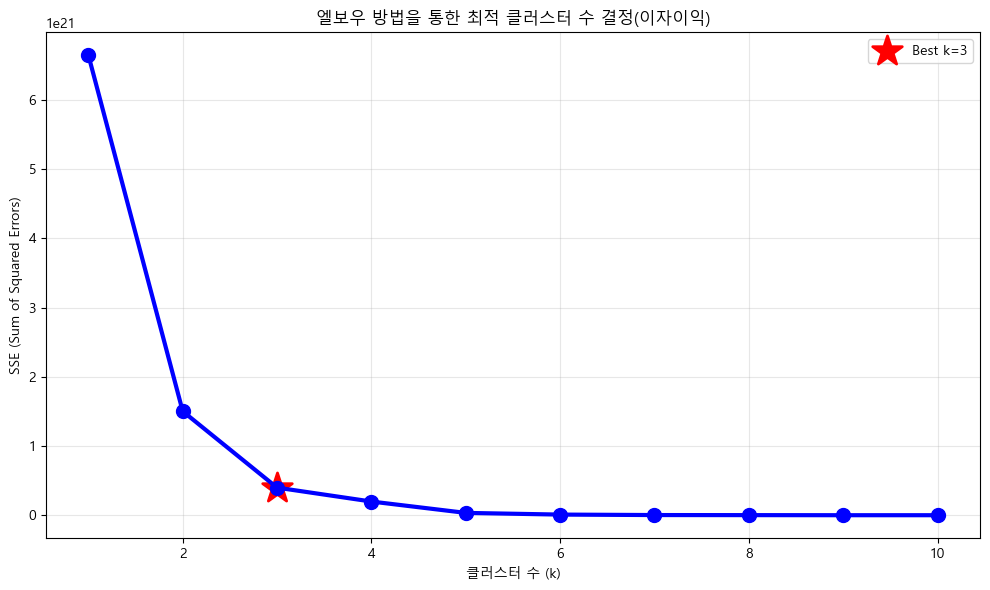

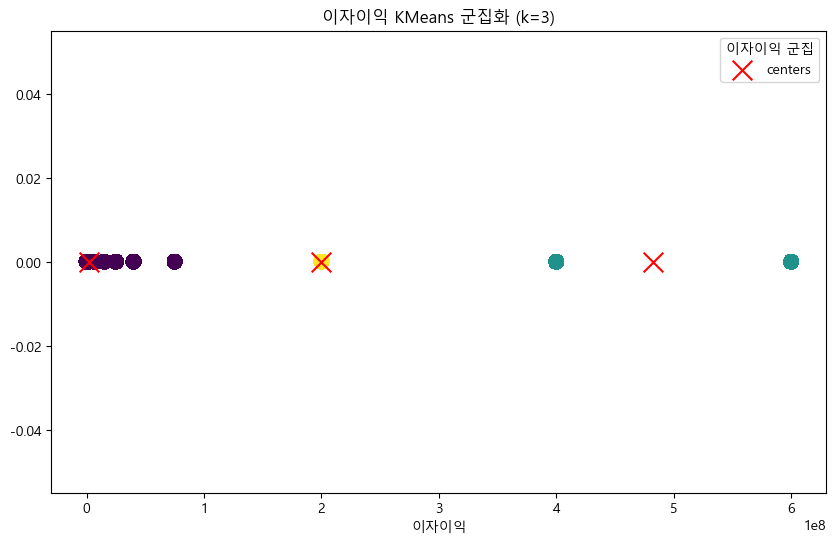

In [7]:
def plot_elbow_and_kmeans(df):
    
    # 편차 기반으로 구한 9구간 추정값 사용 (원화대출 제외)
    nine_segment_medians = {
        '원화대출잔액': 600000000
    }
    

    # 구간 중앙값 딕셔너리 설정
    medians = {
        0: 0, 1: 1500000, 2: 6500000, 3: 15000000, 4: 25000000,
        5: 40000000, 6: 75000000, 7: 200000000, 8: 400000000,
        9: nine_segment_medians['원화대출잔액']
    }
    
    # 기여도 계산
    df_result = df.copy()
    
    if '원화대출잔액' in df.columns:
        df_result['원화대출잔액_기여도'] = df_result['원화대출잔액'].apply(
            lambda x: convert_segment_to_median(x, medians)
        )
    
    # 데이터 전처리
    X = df_result['원화대출잔액_기여도'].values.reshape(-1, 1)

    
    # SSE 계산
    sse = []
    k_range = range(1, 11)
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)
        sse.append(kmeans.inertia_)

    # 엘보우 포인트 자동 추천
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, sse, 'bo-', markersize=10, linewidth=3)
    plt.xlabel('클러스터 수 (k)')
    plt.ylabel('SSE (Sum of Squared Errors)')
    plt.title('엘보우 방법을 통한 최적 클러스터 수 결정(이자이익)')
    plt.grid(True, alpha=0.3)

    # 엘보우 포인트 자동 추천
    sse_diff = np.diff(sse)
    sse_diff2 = np.diff(sse_diff)
    if len(sse_diff2) > 0:
        elbow_idx = np.argmax(sse_diff2) + 2
        elbow_k = k_range[elbow_idx]
        
        print(f"\n=== 엘보우 분석 결과 ===")
        print(f"추천 클러스터 수: k={elbow_k}")

    # 최적 군집수 붉게 표시
    plt.scatter(
    elbow_k, sse[elbow_idx],
    c='red', s=500, marker='*', linewidths=2,
    label=f'Best k={elbow_k}')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # 최적 k로 군집화 수행
    kmeans = KMeans(n_clusters=elbow_k, random_state=42, n_init=10).fit(X)
    labels = kmeans.labels_
    centers = kmeans.cluster_centers_.flatten()

    order = np.argsort(centers)  # 작은 값 → 큰 값 순서
    label_mapping = {old: new for new, old in enumerate(order)}

    sorted_labels = np.array([label_mapping[label] for label in labels])
    df['이자이익 군집'] = sorted_labels

    # 시각화 (산점도)
    plt.figure(figsize=(10,6))
    plt.scatter(X, [0]*len(X), c=labels, cmap='viridis', s=100)
    plt.scatter(centers, [0]*len(centers), c='red', marker='x', s=200, label="centers")
    plt.xlabel("이자이익")
    plt.title(f"이자이익 KMeans 군집화 (k={elbow_k})")
    plt.legend(title="이자이익 군집") 
    plt.show()
        
    
    return df, k_range, sse, elbow_k

# 실행
df, k_values, sse_values, best_k = plot_elbow_and_kmeans(df)

In [8]:
df['이자이익 군집']

0          0
1          0
2          1
3          0
4          0
          ..
2097007    0
2097008    0
2097009    0
2097010    0
2097011    0
Name: 이자이익 군집, Length: 2097012, dtype: int32

## 비이자이익


=== 엘보우 분석 결과 ===
추천 클러스터 수: k=4


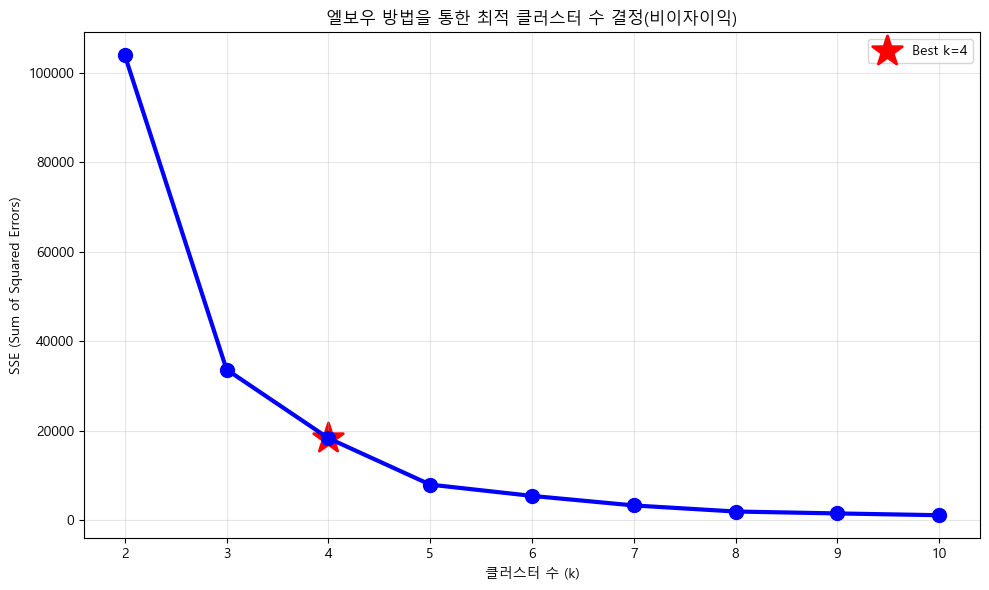

c:\Users\user\anaconda3\envs\py_397\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


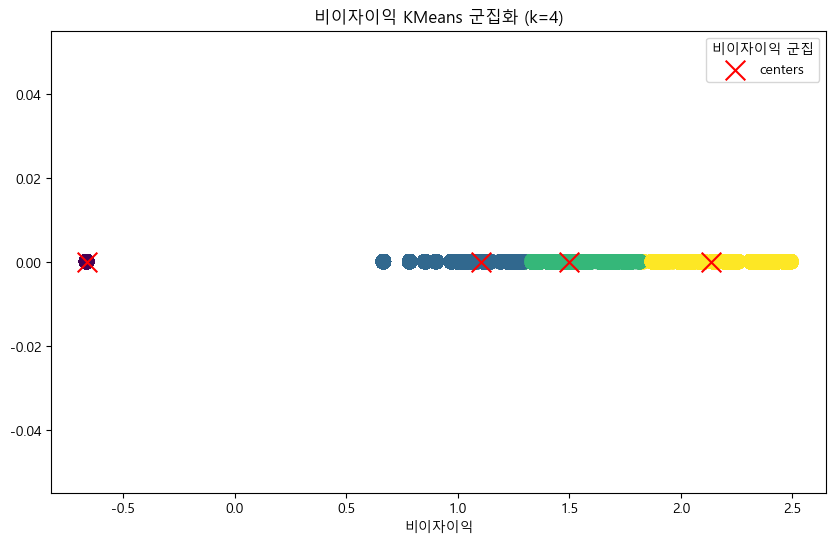

In [9]:

def plot_elbow_and_kmeans(df):
    
    # 편차 기반으로 구한 9구간 추정값 사용 (원화대출 제외)
    nine_segment_medians = {
        '체크카드 거래액 합계': 1400000,
        '펀드잔액': 55000000,
        '방카슈랑스잔액': 60000000
    }
    
    # 구간 중앙값 딕셔너리 설정
    card_medians = {
        0: 0, 1: 2500, 2: 7500, 3: 20000, 4: 65000,
        5: 125000, 6: 225000, 7: 500000, 8: 850000,
        9: nine_segment_medians['체크카드 거래액 합계']
    }
    
    saving_medians = {
        0: 0, 1: 15000, 2: 65000, 3: 300000, 4: 750000,
        5: 3000000, 6: 7500000, 7: 20000000, 8: 40000000,
        9: nine_segment_medians['펀드잔액']
    }
    
    insurance_medians = {
        0: 0, 1: 15000, 2: 65000, 3: 300000, 4: 750000,
        5: 3000000, 6: 7500000, 7: 20000000, 8: 40000000,
        9: nine_segment_medians['방카슈랑스잔액']
    }
    
    # 기여도 계산
    df_result = df.copy()
    
    if '신용카드 거래액 합계' in df.columns:
        df_result['신용카드_기여도'] = df_result['신용카드 거래액 합계'].apply(
            lambda x: convert_segment_to_median(x, card_medians)
        )
    else:
        df_result['신용카드_기여도'] = 0
        
    df_result['체크카드_기여도'] = df_result['체크카드 거래액 합계'].apply(
        lambda x: convert_segment_to_median(x, card_medians)
    )
    
    df_result['펀드_기여도'] = df_result['펀드잔액'].apply(
        lambda x: convert_segment_to_median(x, saving_medians)
    )
    
    df_result['방카슈랑스_기여도'] = df_result['방카슈랑스잔액'].apply(
        lambda x: convert_segment_to_median(x, insurance_medians)
    )
    
    # 총기여도 계산 (원화대출 제외)
    df_result['총기여도'] = (
        df_result['신용카드_기여도'] + 
        df_result['체크카드_기여도'] + 
        df_result['펀드_기여도'] + 
        df_result['방카슈랑스_기여도']
    )
    
    # 데이터 전처리
    X = df_result['총기여도'].values.reshape(-1, 1)
    X_log = np.log1p(X)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_log)
    # SSE 계산
    sse = []
    k_range = range(2, 11)
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_scaled)
        sse.append(kmeans.inertia_)

    # 엘보우 포인트 시각화
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, sse, 'bo-', markersize=10, linewidth=3)
    plt.xlabel('클러스터 수 (k)')
    plt.ylabel('SSE (Sum of Squared Errors)')
    plt.title('엘보우 방법을 통한 최적 클러스터 수 결정(비이자이익)')
    plt.grid(True, alpha=0.3)

    # 엘보우 포인트 자동 추천
    sse_diff = np.diff(sse)
    sse_diff2 = np.diff(sse_diff)
    if len(sse_diff2) > 0:
        elbow_idx = np.argmax(sse_diff2) + 2
        elbow_k = k_range[elbow_idx]
        
        print(f"\n=== 엘보우 분석 결과 ===")
        print(f"추천 클러스터 수: k={elbow_k}")

    # 최적 군집수 붉게 표시
    plt.scatter(
    elbow_k, sse[elbow_idx],
    c='red', s=500, marker='*', linewidths=2,
    label=f'Best k={elbow_k}'
)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # 최적 k로 군집화 수행
    kmeans = KMeans(n_clusters=elbow_k, random_state=42, n_init=10).fit(X_scaled)
    labels = kmeans.labels_
    centers = kmeans.cluster_centers_.flatten()

    order = np.argsort(centers)  # 작은 값 → 큰 값 순서
    label_mapping = {old: new for new, old in enumerate(order)}

    sorted_labels = np.array([label_mapping[label] for label in labels])
    df['비이자이익 군집'] = sorted_labels

    # 시각화 (산점도)
    plt.figure(figsize=(10,6))
    plt.scatter(X_scaled, [0]*len(X_scaled), c=labels, cmap='viridis', s=100)
    plt.scatter(centers, [0]*len(centers), c='red', marker='x', s=200, label="centers")

    plt.xlabel("비이자이익")
    plt.title(f"비이자이익 KMeans 군집화 (k={elbow_k})")
    plt.legend(title="비이자이익 군집")  
    plt.show()
    
    return df, k_range, sse, elbow_k

# 실행
df, k_values, sse_values, best_k = plot_elbow_and_kmeans(df)

In [12]:
df.to_csv('./data/hacktho_FF_final.csv', index=False)